In [51]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

In [52]:
# @title
# donnée fictive pour l'entrainement
data = {'poid':[150, 50, 160, 120, 5, 15, 45, 400]# en gramme
       ,'texture':[1, 9, 5, 2, 1, 8, 3, 1]# 1=lisse 10=rugueux
       ,'couleur':[2, 10, 5, 10, 3, 1, 5, 7]# 1=rouge 10=jaune
       ,'forme':[1, 2, 2, 10, 1, 3, 3, 6]# 1=rond 10=allongée
       ,'pépin':[1, 1, 1, 0, 1, 0, 0, 0]# 1=oui 0=non
       ,'noyau':[0, 0, 0, 0, 0, 0, 1, 1]# 1=oui 0=non
       ,'fruit':['une pomme', 'un citron', 'une orange', 'une banane', 'un raisin', 'une fraise', 'un abricot', 'une mangue']
        }
df = pd.DataFrame(data)

In [53]:
# @title
# changer les nom de fruit en nombre
le = LabelEncoder()
df['code_name'] = le.fit_transform(df['fruit'])

# separer les caracteristique et le nom
x = df[['poid', 'texture', 'couleur', 'forme', 'pépin', 'noyau']]
y = df['code_name']

# crée le cerveau de l'IA
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(x, y)

RandomForestClassifier(random_state=0)

In [54]:
# teste
# poid puis texture(1=lisse 10=rugueux) puis couleur(1=rouge 10=jaune) puis forme(1=rond 10=allongée) pépin (0 ou 1) noyau (0 ou 1)
# l'IA connais la pomme citron orange banane raisin fraise abricot mangue
mystere = pd.DataFrame([[10000, 1, 5, 1, 1, 0]],
                       columns=['poid', 'texture', 'couleur', 'forme', 'pépin', 'noyau']
                       )
pred_prob = model.predict_proba(mystere)
pred = model.predict(mystere)
nom_du_fruit = le.inverse_transform(pred)

for fruit, proba in zip(le.classes_, pred_prob[0]):
   print(f"{fruit} : {proba * 100:.1f}%")

un abricot : 3.0%
un citron : 0.0%
un raisin : 25.0%
une banane : 4.0%
une fraise : 1.0%
une mangue : 13.0%
une orange : 23.0%
une pomme : 31.0%


In [55]:
probabilities_series = pd.Series(pred_prob[0] * 100, index=le.classes_)
probabilities_series

,0
un abricot,3.0
un citron,0.0
un raisin,25.0
une banane,4.0
une fraise,1.0
une mangue,13.0
une orange,23.0
une pomme,31.0


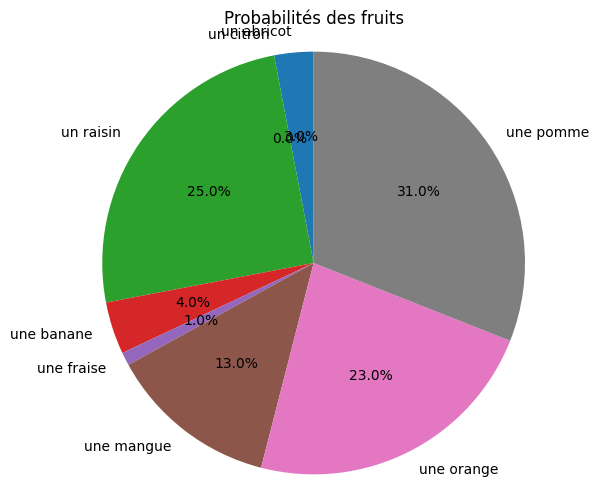

In [56]:
# Create a Series for the pie chart using all classes and their probabilities
plt.figure(figsize=(6, 6))
plt.pie(probabilities_series, labels=probabilities_series.index, autopct='%1.1f%%', startangle=90)
plt.title("Probabilités des fruits")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()